In [50]:
import pandas as pd
import matplotlib.pyplot as plt

forecast = pd.read_csv("../data/processed/forecast.csv")
forecast.head()

,ds,yhat
0,2009-12-06,124632.493438
1,2009-12-13,99033.778852
2,2009-12-20,66205.604398
3,2009-12-27,39066.166026
4,2010-01-10,41168.887496


In [51]:
#last 30 rows future prediction for "date" and "demand"
future_forecast = forecast.tail(30).copy()
future_forecast = future_forecast[["ds", "yhat"]]

future_forecast.columns = ["Date", "Demand"]

In [52]:
#safety stock calculated as std of demand
lead_time = 7 #days
service_level = 1.65  # 95% service level

safety_stock = service_level * future_forecast["Demand"].std() * (lead_time ** 0.5)

LOGIC: <br>
Used variablity in demand as risk buffer <br>
σ = √ (1/n​∑(xi​−μ)^2)
​

In [53]:
#Allocating reorder criteria
future_forecast["Reorder_Point"] = (
    future_forecast["Demand"] * lead_time
) + safety_stock

Formula: <br>
ROP=D×L+SS <br> <br>
(where, <br>
&ensp; D = demand per day <br>
&ensp; L = lead time <br>
&ensp; SS = safety stock <br>
)

In [54]:
stock = 1000000  # initial stock
reorder_quantity = 500000  # amount to refill

stock_list = []
reorder_flag = []

for demand, reorder_point in zip(future_forecast["Demand"], future_forecast["Reorder_Point"]):

    # reduce stock
    stock -= demand

    # check reorder
    if stock <= reorder_point:
        reorder_flag.append(True)
        stock += reorder_quantity   
    else:
        reorder_flag.append(False)

    stock_list.append(stock)

future_forecast["Stock"] = stock_list
future_forecast["Reorder_Flag"] = reorder_flag

In [55]:
#allocating reorder quantity
future_forecast["Order_Quantity"] = (
    future_forecast["Reorder_Point"] - future_forecast["Stock"]
).clip(lower=0)

Model Limitations: <br>
- Assumes Constant lead time <br>
- Stable supply chain <br>
- No cost constraints

In [56]:
#Urgency Level 
def urgency(row):
    if row["Stock"] < row["Reorder_Point"] * 0.7:
        return "High"
    elif row["Stock"] < row["Reorder_Point"]:
        return "Medium"
    else:
        return "Low"

future_forecast["Urgency"] = future_forecast.apply(urgency, axis=1)

In [57]:
#sorting by priority
future_forecast = future_forecast.sort_values(by="Urgency", ascending=False)
future_forecast = future_forecast.sort_values(by="Date")

In [58]:
future_forecast["Stock_Status"] = future_forecast["Reorder_Flag"].map(
    {True: "Reorder", False: "Stock Sustainable"}
)


print("Total Days Requiring Reorder:",
      (future_forecast["Stock_Status"] == "Reorder").sum())

Total Days Requiring Reorder: 5


In [59]:
#KPI metrics
print("Total Reorder Days:", future_forecast["Reorder_Flag"].sum())
print("Average Order Quantity:", future_forecast["Order_Quantity"].mean())

Total Reorder Days: 5
Average Order Quantity: 0.0


In [60]:
future_forecast.tail(10)

,Date,Demand,Reorder_Point,Stock,Reorder_Flag,Order_Quantity,Urgency,Stock_Status
121,2011-12-25,46690.649559,483572.607990,1.109267e+06,False,0.0,Low,Stock Sustainable
122,2011-12-26,71455.528939,656926.763655,1.037812e+06,False,0.0,Low,Stock Sustainable
123,2011-12-27,68343.008413,635139.119968,9.694689e+05,False,0.0,Low,Stock Sustainable
124,2011-12-28,65615.616853,616047.379053,9.038533e+05,False,0.0,Low,Stock Sustainable
125,2011-12-29,63300.271261,599839.959904,8.405531e+05,False,0.0,Low,Stock Sustainable
126,2011-12-30,61417.851703,586663.023002,7.791352e+05,False,0.0,Low,Stock Sustainable
127,2011-12-31,59982.670461,576616.754310,7.191525e+05,False,0.0,Low,Stock Sustainable
128,2012-01-01,30771.849397,372141.006860,6.883807e+05,False,0.0,Low,Stock Sustainable
129,2012-01-02,58476.182127,566071.335967,6.299045e+05,False,0.0,Low,Stock Sustainable
130,2012-01-03,58397.799833,565522.659914,5.715067e+05,False,0.0,Low,Stock Sustainable


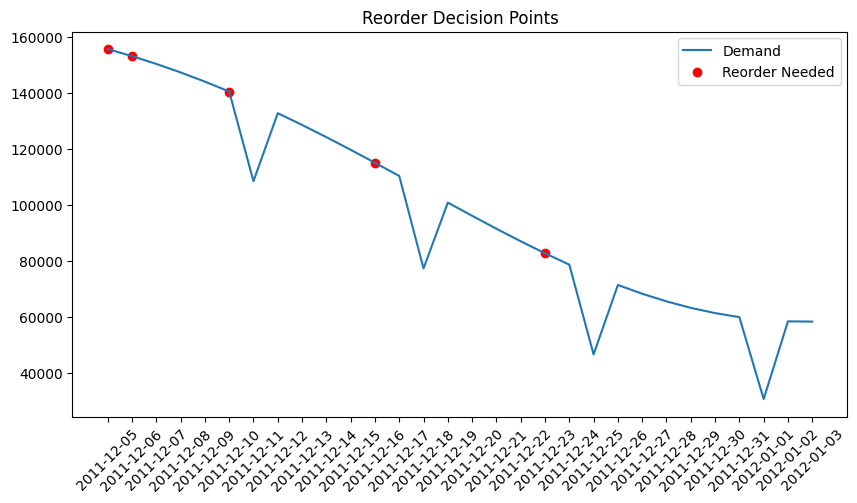

In [61]:
plt.figure(figsize=(10,5))

plt.plot(future_forecast["Date"], future_forecast["Demand"], label="Demand")

plt.scatter(
    future_forecast["Date"][future_forecast["Reorder_Flag"]],
    future_forecast["Demand"][future_forecast["Reorder_Flag"]],
    color='red',
    label="Reorder Needed"
)

plt.legend()
plt.title("Reorder Decision Points")
plt.xticks(rotation=45)
plt.show()